# Wine Quality Prediction using Machine Learning

**This project aims to classify wine quality using machine learning models such as K-Nearest Neighbors (KNN) and Support Vector Machine (SVM).**

In [2]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [77]:
#Loading datasets

df = pd.read_csv(r"C:\Users\niles\OneDrive\Desktop\Riddhi\Internship\Wine quality detection\wine.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Understanding the Data

**This section explores the structure, features, and basic statistics of the dataset.**

In [6]:
print('Shape of data is:')
print(df.shape)
print('\n')

print('Info of data is:')
df.info()
print('\n')

print('description of data is:')
print(df.describe())
print('\n')

print('sum of data is:')
print(df.isnull().sum())
print('\n')

Shape of data is:
(1599, 12)


Info of data is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


description of data is:
       fixed acidity  volatile acidity  citric acid 

## Exploratory Data Analysis (EDA)

**In this section, we visualize the dataset to understand patterns, relationships, and feature impact on wine quality.**

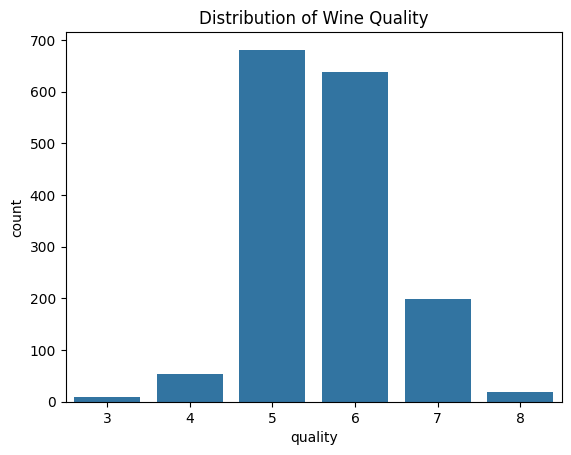

In [83]:
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.show()

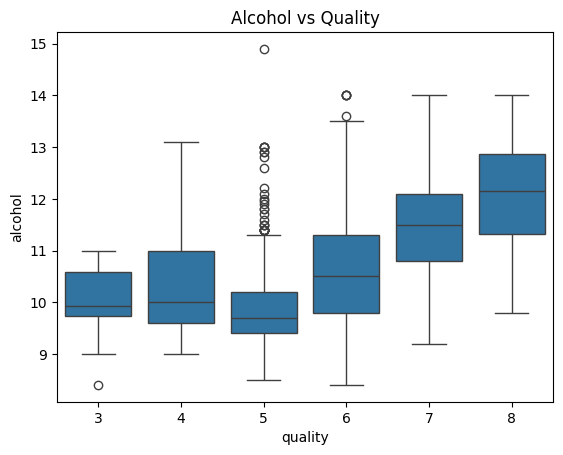

In [86]:
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Alcohol vs Quality")
plt.show()

# Alcohol shows a positive relationship with wine quality

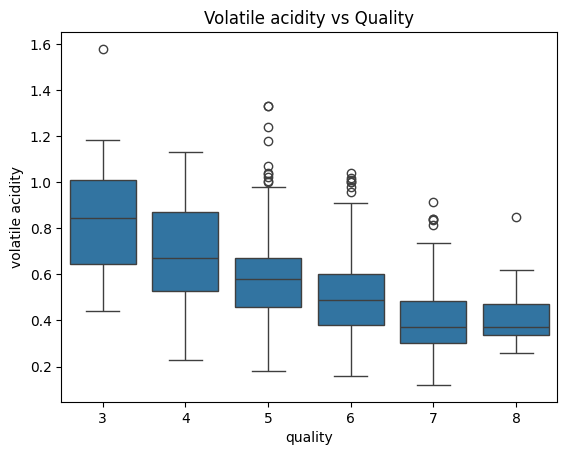

In [87]:
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title("Volatile acidity vs Quality")
plt.show()

# Higher volatile acidity is associated with lower wine quality

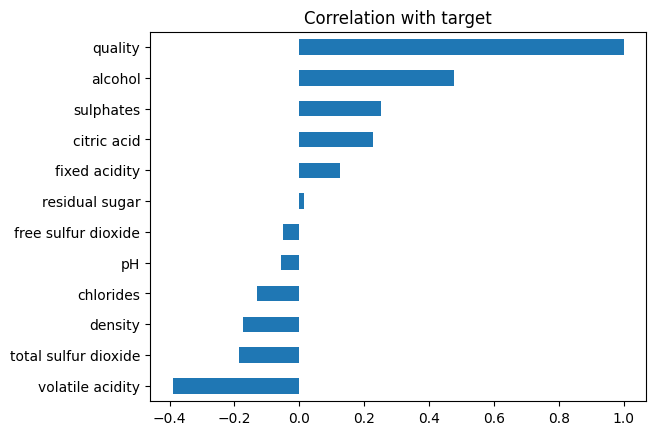

In [88]:
df.corr()['quality'].sort_values().plot(kind='barh')
plt.title("Correlation with target")
plt.show()

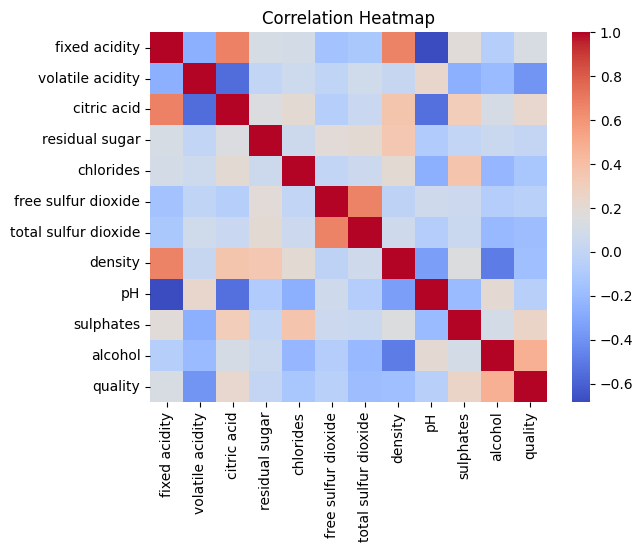

In [85]:
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

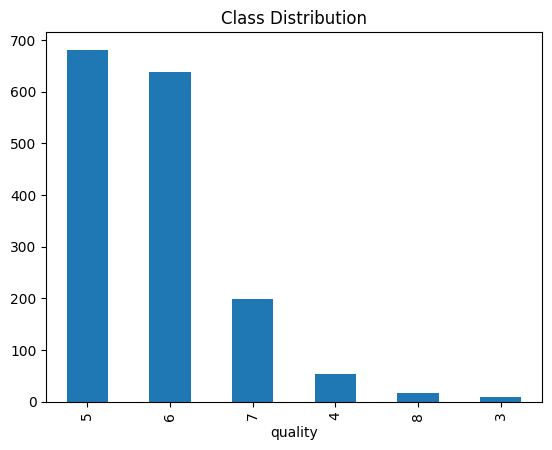

In [82]:
df['quality'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

# Dataset is imbalanced, with more bad quality wines than good ones

## Data Preprocessing

**The target variable is converted into a binary classification problem where:**
**- 0 = Low quality wine**
**- 1 = High quality wine**

In [31]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [32]:
df['quality'].value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [33]:
X = df.drop('quality', axis=1)
Y = df['quality']

print(X.shape)
print(Y.shape)

(1599, 11)
(1599,)


## Splitting the Data

**The dataset is divided into training and testing sets to evaluate model performance.**

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1279, 11)
(320, 11)
(1279,)
(320,)


## Feature Scaling

**Feature scaling is applied to normalize the data so that all features contribute equally to the model.**

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## K-Nearest Neighbors (KNN) Model

**KNN is a distance-based algorithm that classifies data points based on their nearest neighbors.**

In [92]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

Y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(Y_test, Y_pred_knn))
print('\n')
print('confusion matrix: ')
print(confusion_matrix(Y_test, Y_pred_knn))
print('\n')
print('classification report: ')
print(classification_report(Y_test, Y_pred_knn))

KNN Accuracy: 0.88125


confusion matrix: 
[[262  11]
 [ 27  20]]


classification report: 
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       273
           1       0.65      0.43      0.51        47

    accuracy                           0.88       320
   macro avg       0.78      0.69      0.72       320
weighted avg       0.87      0.88      0.87       320



## Support Vector Machine (SVM) Model

**SVM is a supervised learning algorithm that finds the optimal boundary to separate classes.**

In [93]:
svm = SVC(kernel='rbf')
svm.fit(X_train, Y_train)

Y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(Y_test, Y_pred_svm))
print(confusion_matrix(Y_test, Y_pred_svm))
print(classification_report(Y_test, Y_pred_svm))

SVM Accuracy: 0.875
[[268   5]
 [ 35  12]]
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       273
           1       0.71      0.26      0.38        47

    accuracy                           0.88       320
   macro avg       0.80      0.62      0.65       320
weighted avg       0.86      0.88      0.85       320



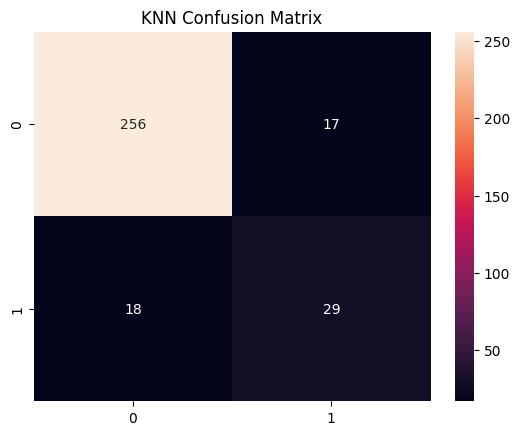

In [51]:
sns.heatmap(confusion_matrix(Y_test, Y_pred_knn), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.show()

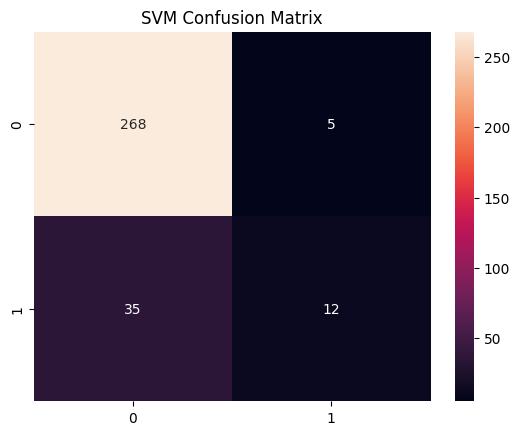

In [84]:
sns.heatmap(confusion_matrix(Y_test, Y_pred_svm), annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

## KNN vs SVM Behavior

**KNN performs slightly better because it adapts to local data patterns, whereas SVM constructs a global decision boundary. Due to class imbalance, SVM tends to favor the majority class, leading to lower recall for high-quality wines.**

In [71]:
knn_acc = accuracy_score(Y_test, Y_pred_knn)
svm_acc = accuracy_score(Y_test, Y_pred_svm)

results = pd.DataFrame({
    'Model': ['KNN', 'SVM'],
    'Accuracy': [knn_acc, svm_acc]
})

print(results)

  Model  Accuracy
0   KNN   0.88125
1   SVM   0.87500


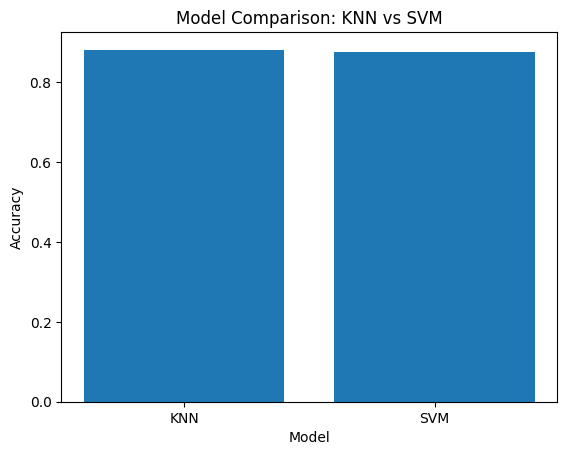

In [74]:
plt.bar(results['Model'], results['Accuracy'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison: KNN vs SVM")
plt.show()

### Initial Model Performance

**Both KNN and SVM models were successfully trained to classify wine quality. The KNN model achieved slightly higher accuracy compared to SVM. However, both models showed difficulty in correctly predicting the minority class (good quality wine), indicating class imbalance in the dataset. Overall, KNN performed slightly better in identifying high-quality wines, while SVM was more precise in predicting low-quality wines.**

## Model Tuning

**Hyperparameters of both models are adjusted to improve performance.**

In [61]:
#Tuning svm

svm = SVC(C=10, gamma=0.01, kernel='rbf', class_weight='balanced')
svm.fit(X_train, Y_train)

Y_pred_svm = svm.predict(X_test)


print("Improved SVM Accuracy:", accuracy_score(Y_test, Y_pred_svm))
print(confusion_matrix(Y_test, Y_pred_svm))
print(classification_report(Y_test, Y_pred_svm))

Improved SVM Accuracy: 0.809375
[[215  58]
 [  3  44]]
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       273
           1       0.43      0.94      0.59        47

    accuracy                           0.81       320
   macro avg       0.71      0.86      0.73       320
weighted avg       0.90      0.81      0.83       320



Initially, the SVM model achieved higher accuracy but struggled to correctly classify high-quality wines due to class imbalance. After applying class weighting, the model significantly improved its ability to detect high-quality wines (recall improved), although overall accuracy decreased. This demonstrates the trade-off between accuracy and recall in imbalanced datasets.

In [ ]:
#Tuning KNN

accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(Y_test, Y_pred))

best_k = k_values[accuracies.index(max(accuracies))]
print("Best K value:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn.fit(X_train, Y_train)

Y_pred_knn = knn.predict(X_test)

knn_acc2 = accuracy_score(Y_test, Y_pred_knn)

print("Improved KNN Accuracy:", knn_acc2)
print(confusion_matrix(Y_test, Y_pred_knn))
print(classification_report(Y_test, Y_pred_knn))

The KNN model performance improved after selecting the optimal value of K using accuracy analysis. Additionally, distance-based weighting allowed closer neighbors to have a greater influence on predictions, resulting in improved classification accuracy and better handling of overlapping data points.

In [62]:
knn_acc = accuracy_score(Y_test, Y_pred_knn)
svm_acc = accuracy_score(Y_test, Y_pred_svm)

results = pd.DataFrame({
    'Model': ['KNN', 'SVM'],
    'Accuracy': [knn_acc, svm_acc]
})

print(results)

  Model  Accuracy
0   KNN  0.890625
1   SVM  0.809375


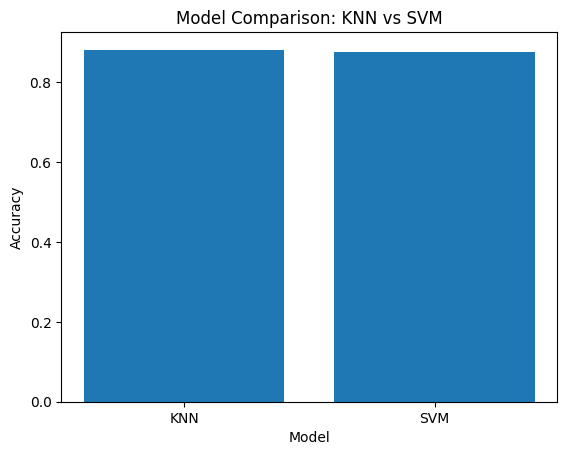

In [75]:
plt.bar(results['Model'], results['Accuracy'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison: KNN vs SVM")
plt.show()

### Final Model Comparison Analysis

**The performance of KNN and SVM models was compared based on accuracy and classification results. The KNN model achieved slightly higher accuracy compared to the SVM model due to its ability to adapt to local patterns in the data, while SVM creates a global decision boundary.**

**However, both models showed difficulty in correctly predicting high-quality wines due to class imbalance in the dataset. The SVM model was more conservative, resulting in fewer false positives but more false negatives for the minority class.**

**Overall, KNN performed slightly better in terms of accuracy, while SVM provided more stable predictions. The choice of model depends on whether overall accuracy or better detection of high-quality wines is prioritized.**

## Conclusion

**In this project, KNN and SVM models were implemented to classify wine quality based on various physicochemical properties. Both models performed well, with KNN achieving slightly higher accuracy after tuning.**

**However, the dataset was imbalanced, which affected the models' ability to correctly predict high-quality wines. SVM initially achieved higher accuracy but struggled with minority class detection. After applying class weighting, its recall for high-quality wines improved, demonstrating the trade-off between accuracy and recall.**

**KNN showed better adaptability to local patterns in the data, making it slightly more effective overall. This project highlights the importance of model selection, hyperparameter tuning, and handling class imbalance in machine learning tasks.**